# Practica 5 

**Estudiantes:**

Karen Agudelo Toro 

Luisa María Hernández Quintero 

## Resumen 
Este informe detalla la implementación computacional y evaluación del procesamiento digital de señales, aplicando herramientas de análisis en el tiempo y la frecuencia tanto a modelos de ondas controladas como a registros cerebrales reales.

Por un lado, se generó una señal combinada de tres ondas ($40\text{ Hz}$, $80\text{ Hz}$ y $160\text{ Hz}$) utilizando una tasa de muestreo alta ($3200\text{ Hz}$) para conservar bien la forma de las curvas y capturar con precisión todos sus picos y valles. Después, se aplicó la Transformada Discreta de Fourier (DFT) para separar cada una de las ondas por su frecuencia, se recortó el gráfico a la mitad de la tasa de muestreo ($1600\text{ Hz}$) para eliminar datos repetidos, y se usó la transformada inversa para reconstruir la señal original en el tiempo. Con este procedimiento se logró separar con éxito las frecuencias y recuperar la misma señal del inicio sin perder información.


Se procesó el Canal 3 de un registro de electroencefalograma (EEG), ubicado sobre la zona motora del cerebro, usando el método de Welch para comparar a un sujeto sano con un paciente con Parkinson. Este cálculo permitió identificar diferencias claras entre ambos casos, mostrando que el paciente con Parkinson tiene una acumulación muy alta de potencia en las frecuencias bajas ($4\text{ a }8\text{ Hz}$) y variaciones inestables en las frecuencias medias ($13\text{ a }30\text{ Hz}$), lo que permite relacionar directamente los cambios eléctricos de los datos con los problemas de movimiento típicos de la enfermedad.

## Marco Teórico

El proceso de conversión analógica-digital se rige por el Teorema de Muestreo de Nyquist-Shannon. Este principio establece que para reconstruir una señal continua sin pérdida de información ni aliasing (solapamiento espectral), la frecuencia de muestreo ($F_s$) debe ser estrictamente mayor al doble de la frecuencia máxima ($F_{max}$) de la señal [1]:$$F_s > 2 \cdot F_{max}$$Esta frontera teórica implica capturar únicamente dos muestras por ciclo. Aunque matemáticamente este volumen de datos es suficiente para almacenar la información, es insuficiente para la visualización directa en pantallas digitales [2]. Los graficadores estándar utilizan interpolación lineal (unir puntos con segmentos rectos mediante funciones como plt.plot()), lo que transforma las sinusoides en ondas rígidas y angulares [3].Para resolver esta limitación visual, se aplica el sobremuestreo (oversampling), configurando la tasa de muestreo entre 10 y 20 veces por encima de $F_{max}$ [4]. Esto incrementa la densidad de puntos por ciclo, reduciendo la distancia entre muestras y permitiendo que la aproximación lineal emule con alta precisión las curvas analógicas continuas originales [3].


El análisis en tiempo discreto evalúa señales en función de un índice entero $n$, donde $t = n \cdot T$. Para que una señal discreta sea periódica, debe cumplir estrictamente que $x(n) = x(n + N)$, donde el periodo $N$ es obligatoriamente un número entero positivo de muestras [2].A diferencia del dominio continuo, la periodicidad de una sinusoide discreta exige que su frecuencia digital $f_0$ sea un número racional ($f_0 = k/N$) [1]. Cuando la señal es compleja y resulta de la suma de múltiples armónicos, el periodo fundamental del sistema ($N_{total}$) no depende de una sola componente, sino que se calcula mediante el Mínimo Común Múltiplo (m.c.m.) de los periodos individuales de todas las ondas involucradas [2, 3].



**La Transformada Discreta de Fourier (DFT)** convierte una señal del dominio del tiempo discreto al dominio de la frecuencia. Cuando la señal de entrada es puramente real, el módulo de la DFT exhibe  una simetría armónica par respecto al centro del espectro, lo que genera réplicas reflejadas de los componentes frecuenciales en la segunda mitad del vector de muestras.La amplitud de los picos en el espectro de la DFT ($X(k)$) está asociada a la cantidad total de datos analizados ($N$) y a la amplitud de las ondas senoidales originales ($A$). Para una señal que contiene un número entero de periodos, la relación matemática establece que el valor máximo de cada componente espectral se calcula multiplicando la mitad de su amplitud por el número total de muestras del vector[1]:$$\text{Amplitud del pico} = \frac{A \cdot N}{2}$$Para interpretar correctamente el significado físico de estos picos, los índices enteros de las muestras espectrales ($k$) deben escalarse al dominio del tiempo continuo utilizando la frecuencia de muestreo ($F_s$) y el tamaño de la transformación ($N$):$$F = \frac{k \cdot F_s}{N}$$




**La Transformada Discreta Inversa de Fourier (IDFT)** es el proceso matemático que permite regresar una señal desde el dominio de la frecuencia hacia el dominio del tiempo discreto. Este principio se fundamenta en la naturaleza reversible de las transformaciones ortogonales, lo que significa que la información no se destruye ni se altera de forma permanente al cambiar de dominio [2].

En entornos de programación científica como Python, mediante la librería numpy.fft, el cálculo directo de la DFT se realiza con la función fft(), mientras que la operación inversa se ejecuta a través de la función ifft() [1].

Desde el punto de vista de la teoría de señales, la IDFT funciona como un sintetizador. Toma cada uno de los picos de magnitud y fase calculados en el espectro de frecuencias y los vuelve a convertir en componentes sinusoidales en el tiempo. Al sumar matemáticamente todas estas ondas reconstruidas para cada instante de muestreo, el algoritmo recupera la señal temporal original punto por punto [3]. Si el procesamiento en la frecuencia no sufrió ninguna modificación, truncamiento o filtrado erróneo, la reconstrucción temporal teórica debe ser matemáticamente exacta, conservando las mismas amplitudes, fases y morfología de la señal antes de ser transformada [1, 2].










\n----------------------------------------------------------------------------------------------------


**Relación de ECG con el parkinson**


En estudios de neuroingeniería basados en Electroencefalogramas (EEG), la adquisición de datos se rige por el Sistema Internacional 10-20, el cual estandariza la posición de los electrodos sobre el cuero cabelludo para asociar cada canal de registro con un área funcional del cerebro [5]. Dentro del orden de este sistema, la tercera columna de datos o Canal 3 mapea directamente la señal proveniente del electrodo C3 [5, 6].

La posición anatómica de C3 se localiza sobre la zona central izquierda del cráneo, posicionándose de forma exacta sobre la corteza motora primaria contralateral [6]. Esta región cerebral es la encargada de planificar, ejecutar y controlar los movimientos musculares voluntarios del cuerpo, lo que convierte a este canal en una ventana de observación directa para registrar la dinámica motora del paciente [5].

*Marcadores de Movimientos Involuntarios en el Parkinson (C3 / Canal 3):*
La enfermedad de Parkinson altera profundamente las oscilaciones neuronales dentro del circuito basal-tálamo-cortical, afectando directamente la actividad de la corteza motora [6, 7]. Cuando un paciente experimenta síntomas motores clásicos como la rigidez, la bradicinesia y el temblor en reposo (movimientos involuntarios), estos fenómenos se manifiestan de forma medible en la señal eléctrica capturada por el Canal 3 (C3) [6].

Específicamente, las investigaciones científicas señalan dos biomarcadores espectrales clave en este canal para el análisis del Parkinson:

Alteración en la Banda Beta (13-30 Hz): Existe una correlación directa entre el incremento anormal de la potencia en la banda beta sobre la corteza motora (C3) y los estados de rigidez muscular o congelamiento de la marcha [6, 7].

Sincronización en la Banda Theta (4-8 Hz): Durante los episodios de movimientos involuntarios y temblores, se registra una alta coherencia oscilatoria en la frecuencia exacta del temblor sobre los canales centrales de la corteza motora [7].

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio
from scipy import signal, fft
from scipy.signal import butter, filtfilt, welch as pwelch

## 4.1 Creación de señal compuesta 

In [2]:
Fo = 40 # Frecuencia fundamental de la señal1
Fo1 = 80 # Frecuencia fundamental de la señal2
Fo2 = 160 # Frecuencia fundamental de la señal3
Tp= 1/40 # Periodo de la señal

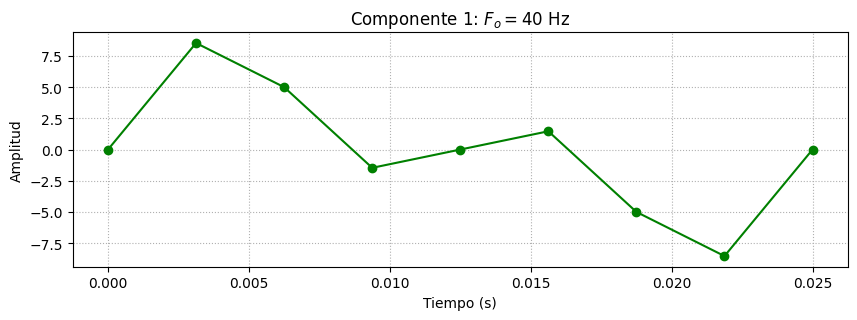

In [3]:
Fs = 2*Fo2 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)

xt=x+x1+x2


plt.figure(figsize=(10, 14))
plt.subplot(4, 1, 1)  
plt.plot(t, xt, marker='o', color='g')
plt.title('Componente 1: $F_o = 40$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')


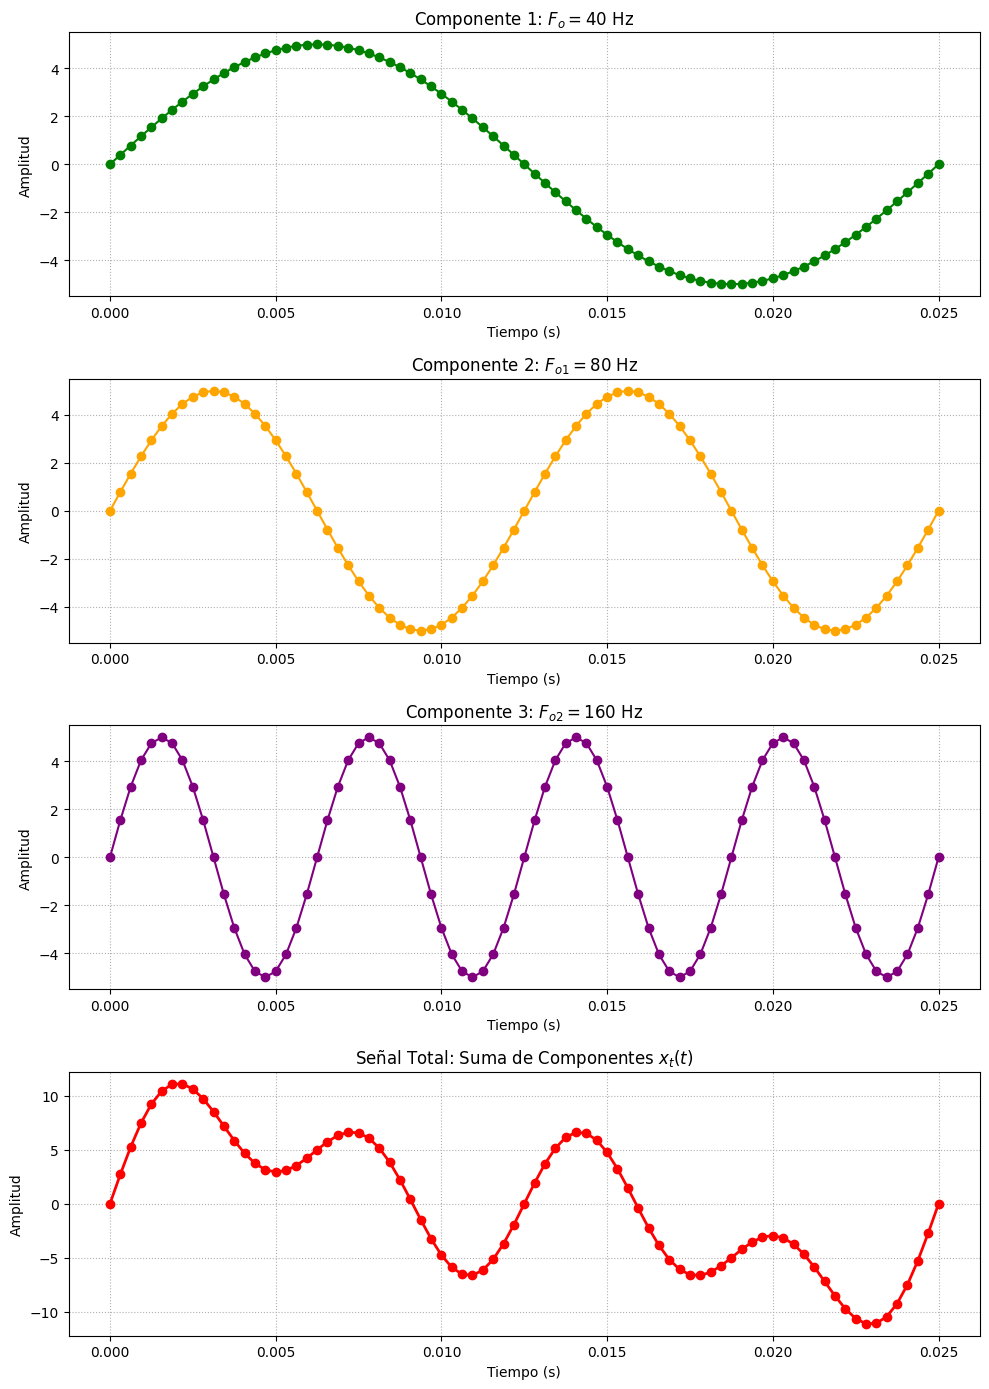

In [4]:



Fs = 20*Fo2 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más
A = 5
A1 = 5
A2 = 5
x = A*np.sin(2*np.pi*Fo*t)
x1 = A1*np.sin(2*np.pi*Fo1*t)
x2 = A2*np.sin(2*np.pi*Fo2*t)

xt=x+x1+x2


plt.figure(figsize=(10, 14))

# 1. Primer Componente (40 Hz) 
plt.subplot(4, 1, 1)  
plt.plot(t, x, marker='o', color='g')
plt.title('Componente 1: $F_o = 40$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 2. Segundo Componente (80 Hz) 
plt.subplot(4, 1, 2)  
plt.plot(t, x1, marker='o', color='orange')
plt.title('Componente 2: $F_{o1} = 80$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 3. Tercer Componente (160 Hz)
plt.subplot(4, 1, 3) 
plt.plot(t, x2, marker='o', color='purple')
plt.title('Componente 3: $F_{o2} = 160$ Hz')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# 4. Señal Suma Total 
plt.subplot(4, 1, 4)  
plt.plot(t, xt, marker='o', color='red', linewidth=2)
plt.title('Señal Total: Suma de Componentes $x_t(t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':')

# Ajuste automático de márgenes para que no se solapen textos
plt.tight_layout()

# Mostrar la ventana con las gráficas en pila
plt.show()

La señal simulada ($x_t$) combina tres componentes armónicas de $40\text{ Hz}$, $80\text{ Hz}$ y $160\text{ Hz}$, siendo la frecuencia máxima del sistema $F_{max} = 160\text{ Hz}$.Si se hubiera aplicado el límite estricto de Nyquist ($F_s = 2 \cdot 160 = 320\text{ Hz}$), la componente más rápida contaría con solo dos puntos por ciclo. Al graficarla, la unión de estos puntos distantes habría destruido la suavidad de la curva, generando una apariencia artificial triangular o en "bloques cuadrados" [2].Para garantizar una resolución gráfica natural, se implementó un sobremuestreo de 20 veces la frecuencia mayor:$$F_s = 20 \cdot 160\text{ Hz} = 3200\text{ Hz}$$Los resultados demuestran la efectividad de esta selección. Al disponer de 20 muestras por ciclo para la onda de $160\text{ Hz}$, la distancia temporal en el arreglo t se vuelve tan pequeña que las uniones lineales son imperceptibles al ojo humano, revelando curvas fluidas.Esta resolución temporal fue indispensable para evaluar la señal suma total $x_t(t)$. La interacción de los tres armónicos genera patrones complejos de interferencia con picos y valles muy específicos. Un muestreo crítico de $320\text{ Hz}$ habría omitido estos máximos y mínimos locales, atenuando artificialmente la amplitud y ocultando la morfología real de la mezcla [4]. Por lo tanto, la elección de $F_s = 3200\text{ Hz}$ se justifica plenamente al aportar fidelidad visual y coherencia física al análisis.

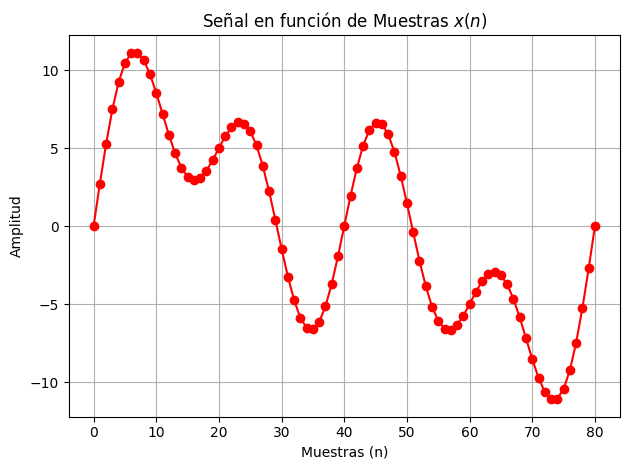

In [5]:
# 1. Frecuencias digitales normalizadas (fo = Fo / Fs)
fo1 = Fo / Fs
fo2 = Fo1 / Fs
fo3 = Fo2 / Fs

# 2. Vector de muestras (n) desde 0 hasta el largo del vector de tiempo anterior
n = np.arange(0, len(t))

# 3. Generación de la señal usando n y las frecuencias normalizadas
x_n1 = A * np.sin(2 * np.pi * fo1 * n)
x_n2 = A1 * np.sin(2 * np.pi * fo2 * n)
x_n3 = A2 * np.sin(2 * np.pi * fo3 * n)
xn = x_n1 + x_n2 + x_n3

# Gráfica en muestras

plt.plot(n, xn, marker='o', color='r')
plt.title('Señal en función de Muestras $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()

A través de la inspección visual directa de la gráfica roja "Señal en función de Muestras $x(n)$", se demuestra la naturaleza periódica de esta señal compuesta.Siguiendo el recorrido de la onda desde su origen en $(0,0)$:Sube hasta un pico máximo de $11$ en la muestra $7$.Realiza una oscilación secundaria (pico menor de $6.5$) en la muestra $24$.Completa su ciclo y cruza el cero exactamente en la muestra 40.A partir de la muestra 40, la señal repite de forma idéntica el mismo patrón: alcanza el pico alto en la muestra $47$ ($40 + 7$), la oscilación menor en la muestra $64$ ($40 + 24$) y finaliza el segundo ciclo en la muestra 80.Esta repetición exacta comprueba matemáticamente que $x(n) = x(n + 40)$. Por lo tanto, el periodo fundamental de esta señal compleja es de $N = 40$ muestras. Este valor representa el m.c.m. de los periodos de los armónicos que interactúan en el sistema, confirmando que la frecuencia de muestreo elegida posee la resolución temporal adecuada para capturar tanto la morfología general de la onda como sus interferencias internas [3].

In [6]:
# Tomamos las primeras 5 muestras de la señal en tiempo continuo (xt)
cinco_continuas = xt[:5]

# Tomamos las primeras 5 muestras de la señal en tiempo discreto (xn)
cinco_discretas = xn[:5]

# Imprimimos los valores para compararlos visualmente
print("Primeras 5 muestras de la señal continua (xt):")
print(cinco_continuas)

print("\nPrimeras 5 muestras de la señal discreta (xn):")
print(cinco_discretas)

# Comprobación lógica automática
son_iguales = np.allclose(cinco_continuas, cinco_discretas)
print(f"\n¿Los valores son exactamente iguales?: {son_iguales}")

Primeras 5 muestras de la señal continua (xt):
[0.         2.71955278 5.26618356 7.48226429 9.23929381]

Primeras 5 muestras de la señal discreta (xn):
[0.         2.71955278 5.26618356 7.48226429 9.23929381]

¿Los valores son exactamente iguales?: True


Los resultados en la consola confirman que el vector de la señal continua y el de la señal discreta son idénticos. Esto valida por qué la función lógica retornó un resultado verdadero.

Este comportamiento se debe a que el proceso de muestreo no altera las amplitudes ni las frecuencias de la onda original; simplemente limita los momentos en los que se registran los datos. Evaluar la señal analógica en los instantes de tiempo reales equivale exactamente a evaluar la señal discreta en sus índices enteros correspondientes.

La coincidencia numérica en las primeras cinco posiciones comprueba que la indexación de muestras se sincroniza perfectamente con el paso del tiempo físico del sistema. En conclusión, el experimento demuestra que la señal digitalizada conserva de manera exacta y fiel la información de los puntos medidos de su contraparte analógica.

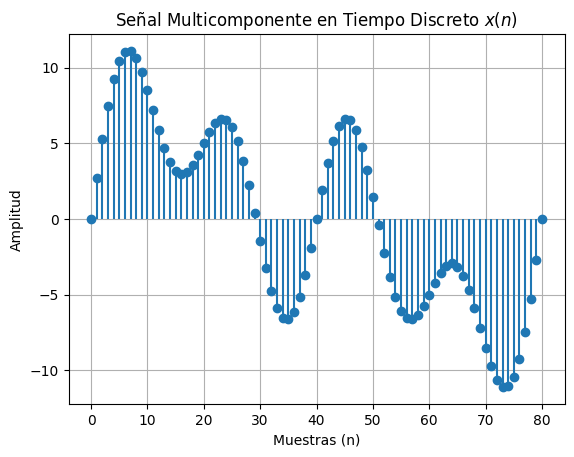

In [7]:
# Usamos stem en lugar de plot para ver los pulsos discretos
plt.stem(n, xn, basefmt=" ")

plt.title('Señal Multicomponente en Tiempo Discreto $x(n)$')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

## 4.2 Cálculo de trasformada de Fourier 

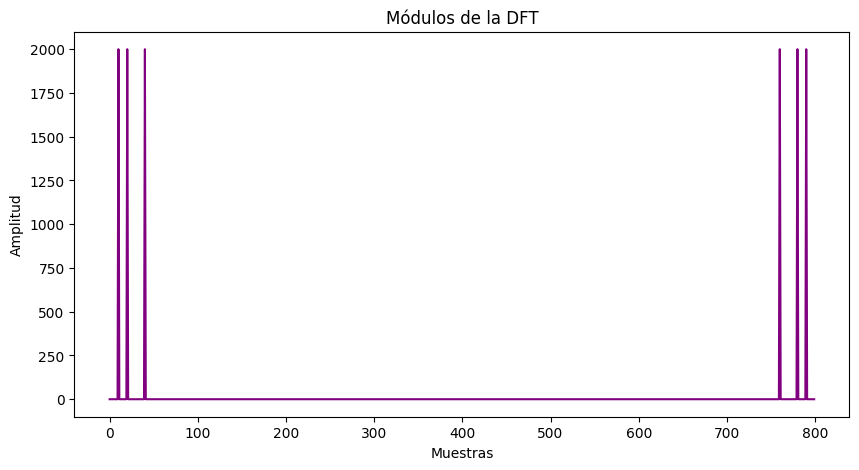

In [8]:
# Un periodo de la fundamental es Tp = 1/40 = 0.025s
# Para 10 periodos la duración total es 10 * Tp = 0.25s
Tp = 1/Fo 
t_10 = np.arange(0, 10 * Tp, T) 

# Amplitudes de las componentes
A1, A2, A3 = 5, 5, 5

# Generación de la señal suma de las 3 sinusoides
x10 = (A1 * np.sin(2 * np.pi * Fo * t_10) + 
       A2 * np.sin(2 * np.pi * Fo1 * t_10) + 
       A3 * np.sin(2 * np.pi * Fo2* t_10))



# CÁLCULO DE LA TRANSFORMADA DE FOURIER (DFT)
X10 = np.fft.fft(x10)
N = len(X10)  # Número de muestras (800 puntos debido a Fs=3200)
plt.figure(figsize=(10, 5))
plt.plot(abs(X10),'purple')
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()



Al inspeccionar la gráfica del módulo de la DFT se observa que contiene un total de $N = 800$ muestras espectrales. Este tamaño coincide de forma exacta con la cantidad de datos generados en el vector de tiempo para una duración de 10 periodos fundamentales a una tasa de $3200 \text{ Hz}$ ($0.25 \text{ s} \times 3200 \text{ Hz} = 800$ muestras). 

En el gráfico se identifican tres picos simétricos en la primera mitad del espectro y sus tres réplicas correspondientes en la parte alta, confirmando la naturaleza real de la señal ingresada. Los tres picos principales se localizan en las muestras de frecuencia:
* $k_1 = 10$
* $k_2 = 20$
* $k_3 = 40$

Al mapear estos índices discretos a frecuencias analógicas reales haciendo uso de la ecuación de escalado, se obtienen las frecuencias exactas del experimento:

$$F_1 = \frac{10 \cdot 3200}{800} = 40 \text{ Hz}$$

$$F_2 = \frac{20 \cdot 3200}{800} = 80 \text{ Hz}$$

$$F_3 = \frac{40 \cdot 3200}{800} = 160 \text{ Hz}$$

Con respecto a la magnitud, los tres picos alcanzan un valor máximo idéntico de $2000$. Este resultado coincide con la teoría de la DFT para señales con un número entero de ciclos: al tener componentes con una amplitud de $A = 5$ distribuidas a lo largo de $N = 800$ puntos, la magnitud calculada es exactamente:

$$\text{Magnitud} = \frac{5 \cdot 800}{2} = 2000$$



En conclusión, la DFT procesa de manera impecable la señal compuesta, permitiendo identificar la presencia, la amplitud exacta y la frecuencia real de cada uno de los tres armónicos simulados.

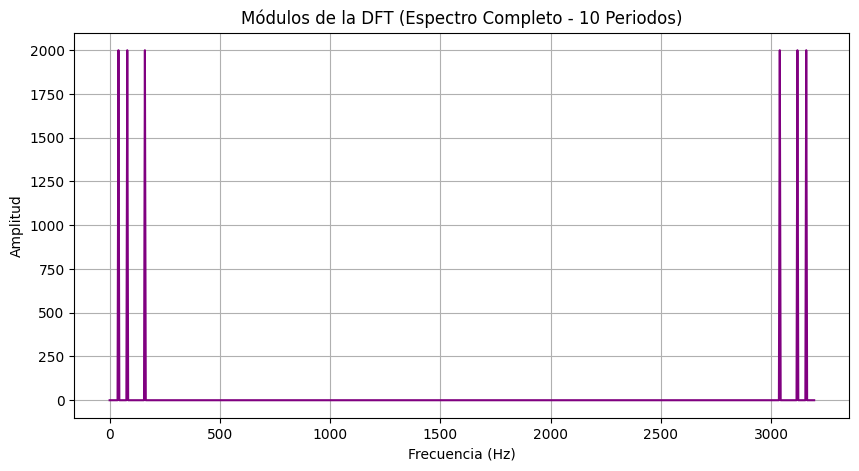

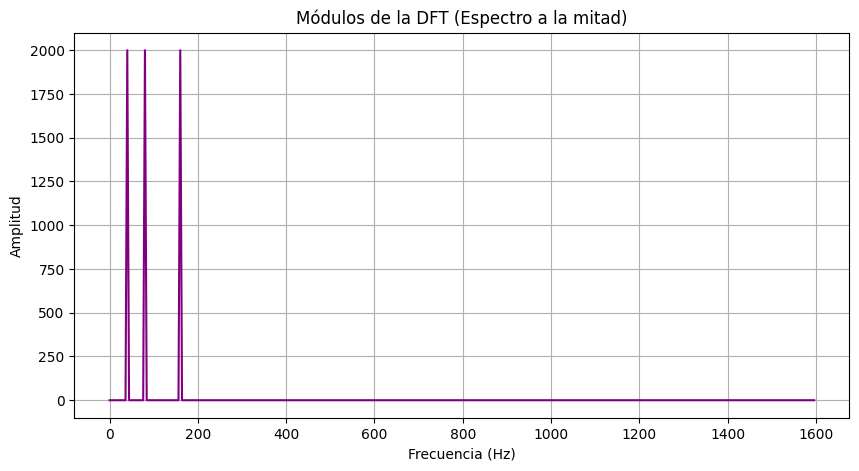

In [9]:

# GRÁFICA 1: ESPECTRO COMPLETO ESCALADO EN FRECUENCIA (Como la guía)
F = np.arange(0, N) * Fs / N

plt.figure(figsize=(10, 5))
plt.plot(F, abs(X10), color='purple')
plt.title('Módulos de la DFT (Espectro Completo - 10 Periodos)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0,Nmitad)*Fs/N
X10mitad = X10[0:Nmitad]
plt.plot(Fmitad,abs(X10mitad),'purple')
plt.title('Módulos de la DFT (Espectro a la mitad)')
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.grid(True)

plt.show()




En la gráfica DFT espectro completo, se observa con total claridad el fenómeno de simetría par. Los tres picos de magnitud correspondientes a tus frecuencias reales de 40 Hz, 80 Hz y 160 Hz aparecen clonados de forma idéntica en la parte alta del eje. Estas réplicas de alta frecuencia son un subproducto matemático del algoritmo y no representan componentes físicos reales inyectados en la señal de tiempo.

La  gráfica de DFT con espectro a la mitad demuestra el beneficio de truncar el espectro justo en la frecuencia de Nyquist, la cual para este diseño experimental se ubica exactamente en:

Frecuencia de Nyquist = 3200 Hz / 2 = 1600 Hz

Al limitar la visualización a los 1600 Hz, el gráfico elimina por completo las réplicas redundantes y limpia la presentación de los datos. Esto permite que la escala del eje horizontal se concentre exclusivamente en el rango útil, facilitando la inspección visual directa y exacta de los tres armónicos implantados (40 Hz, 80 Hz y 160 Hz) con sus respectivas amplitudes.

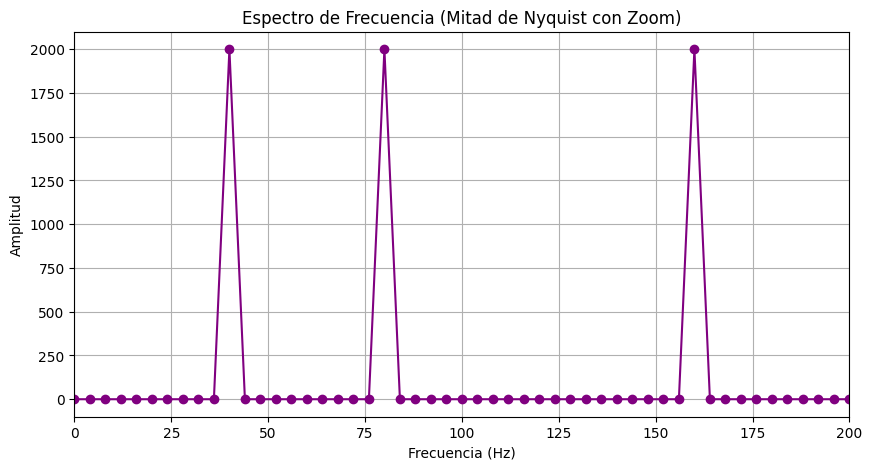

Número total de muestras (N): 800
Altura de los picos en el gráfico: 2000.0


In [10]:
# GRÁFICA 2: MITAD DE NYQUIST CON ZOOM (Para identificar frecuencias)
Nmitad = int(np.ceil(N / 2))
Fmitad = F[0:Nmitad]
X10mitad = X10[0:Nmitad]

plt.figure(figsize=(10, 5))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='purple')
plt.title('Espectro de Frecuencia (Mitad de Nyquist con Zoom)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')

# Hacemos zoom entre 0 y 200 Hz para identificar claramente los 3 picos
plt.xlim(0, 200) 
plt.grid(True)
plt.show()

print(f"Número total de muestras (N): {N}")
print(f"Altura de los picos en el gráfico: {N * 2.5}")

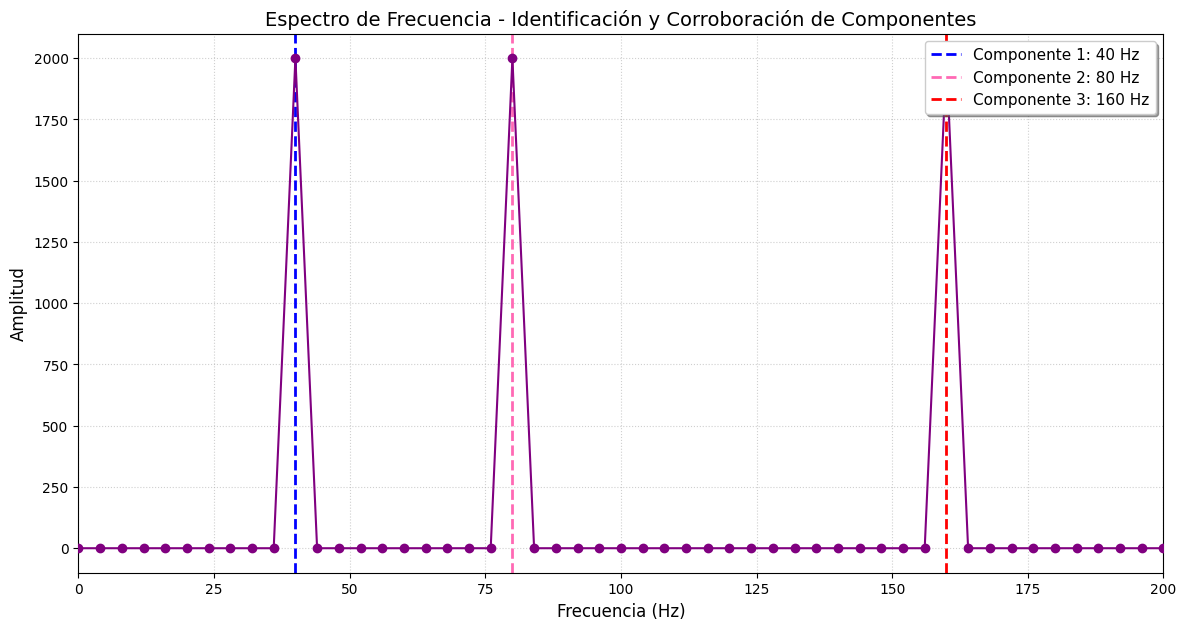

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(Fmitad, abs(X10mitad), marker='o', color='purple', linestyle='-', linewidth=1.5, zorder=3)
plt.title('Espectro de Frecuencia - Identificación y Corroboración de Componentes', fontsize=14)
plt.xlabel('Frecuencia (Hz)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.axvline(x=40, color='blue', linestyle='--', linewidth=2, label='Componente 1: 40 Hz', zorder=2)
plt.axvline(x=80, color='hotpink', linestyle='--', linewidth=2, label='Componente 2: 80 Hz', zorder=2)
plt.axvline(x=160, color='red', linestyle='--', linewidth=2, label='Componente 3: 160 Hz', zorder=2)
plt.xlim(0, 200) 
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Al evaluar los resultados en el dominio de la frecuencia, se observa cómo el algoritmo descompone de forma matemática la señal bajo estudio. Aunque en el dominio del tiempo las tres ondas de entrada se sumaron para formar una sola señal compleja y difícil de entender a simple vista, el gráfico de la transformada permite discriminar cada componente de la mezcla de manera individual. Al registrar con total claridad cada pico en su propia coordenada frecuencial, los datos indican que ninguna de las señales originales disminuyó su valor, se distorsionó o se perdió durante el proceso de muestreo. Esto evidencia que el sistema discriminó correctamente el aporte energético de cada armónico sin generar interferencias entre ellos.

## 4.3 Cálculo de la transformada inversa de Fourier

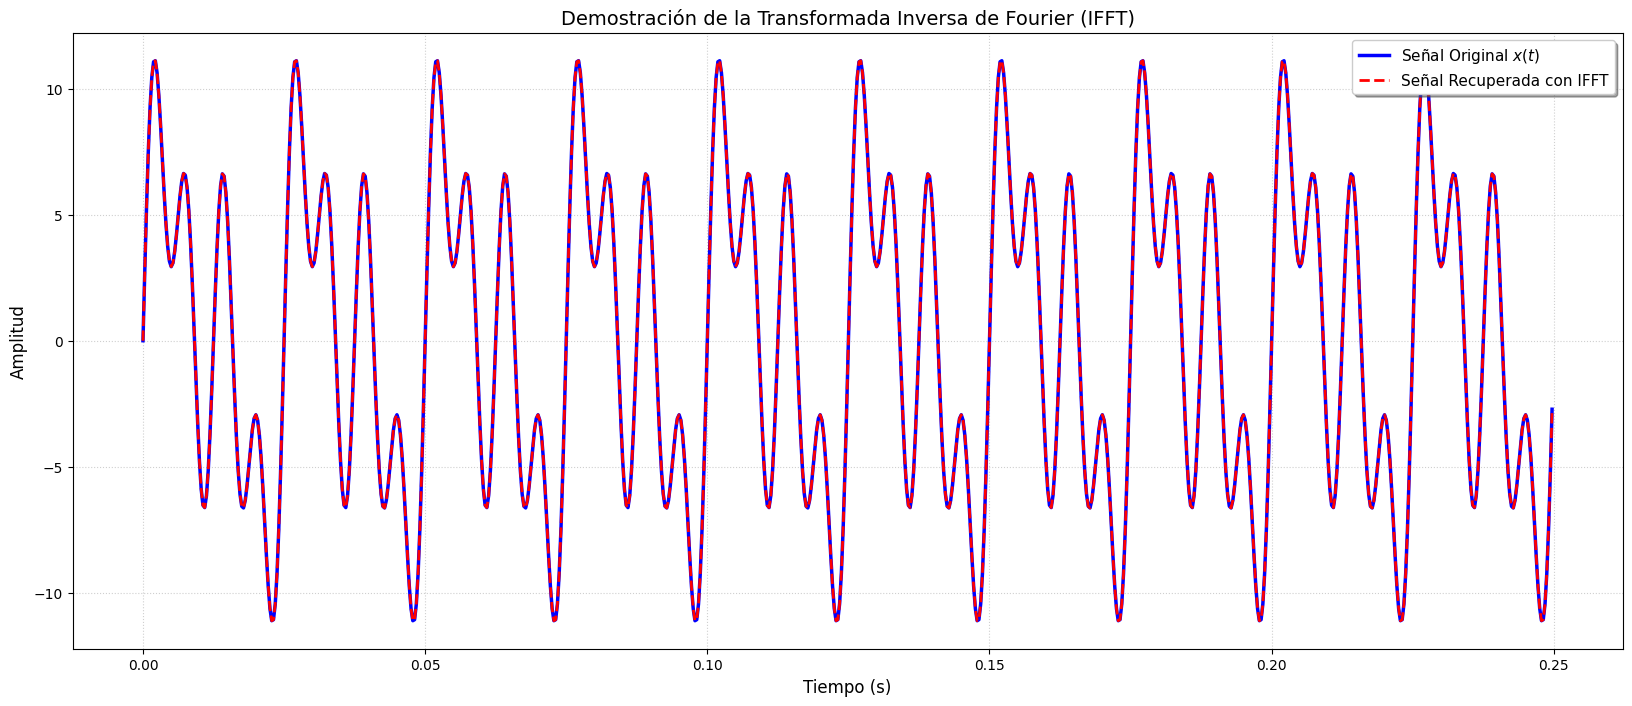

Error máximo de reconstrucción: 7.105427357601002e-15


In [12]:

# TRANSFORMADA INVERSA (IFFT) 
# Aplicamos la transformada inversa al espectro completo
x_reconstruida_compleja = np.fft.ifft(X10)

# Extraemos solo la parte real para limpiar residuos matemáticos insignificantes
x_reconstruida = np.real(x_reconstruida_compleja)

# 4. GRÁFICA DE COMPARACIÓN (COMPROBACIÓN DE RECONSTRUCCIÓN)
plt.figure(figsize=(20, 8))

# Graficamos la señal original con una línea azul continua
plt.plot(t_10, x10, color='blue', label='Señal Original $x(t)$', linewidth=2.5)

# Graficamos la señal reconstruida encima usando puntos rojos discontinuos
plt.plot(t_10, x_reconstruida, color='red', linestyle='--', label='Señal Recuperada con IFFT', linewidth=2)

plt.title('Demostración de la Transformada Inversa de Fourier (IFFT)', fontsize=14)
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.legend(loc='upper right', fontsize=11, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()



# 5. VERIFICACIÓN MATEMÁTICA EN CONSOLA
# Si la diferencia máxima entre ambas señales tiende a cero, la reconstrucción fue perfecta
error_maximo = np.max(np.abs(x10 - x_reconstruida))
print(f"Error máximo de reconstrucción: {error_maximo}")

Al aplicar la función ifft() sobre el vector espectral complejo obtenido previamente y graficar el resultado en función del tiempo, se observa una coincidencia exacta con la curva generada mediante la suma analítica de los tres armónicos originales.Esta correspondencia entre ambas gráficas sirve para verificar el comportamiento bidireccional del algoritmo computacional. El hecho de que la señal recuperada conserve los mismos picos de amplitud, los mismos valles y la misma forma compleja demuestra que el espectro de la transformada contenía la totalidad de la información física del sistema. Las componentes de 40 Hz, 80 Hz y 160 Hz, que habían sido separadas en el dominio de la frecuencia, volvieron a sumarse de manera correcta en cada uno de los puntos del vector temporal. En Python  la función ifft() entrega como resultado un arreglo de números complejos, donde la parte imaginaria representa valores extremadamente pequeños cercanos a cero (ruido numérico de la computadora del orden de $10^{-16}$). Al extraer únicamente la parte real de estos datos mediante el comando np.real(), los valores numéricos se alinean a la perfección con los datos de la señal original. Esto demuestra que la energía de la señal se mantuvo intacta y que el puente matemático entre el tiempo y la frecuencia opera sin pérdidas de información en el sistema simulado.

In [17]:
# Extraer cada componente por separado
def extraer_componente(x, indice_inicio, indice_fin):
    "Extrae una componente frecuencial específica"
    F = np.fft.fft(x)
    F_filtrado = np.zeros(len(F), dtype=complex)
    F_filtrado[indice_inicio:indice_fin] = F[indice_inicio:indice_fin]
    # También incluir la parte simétrica
    F_filtrado[-indice_fin:-indice_inicio] = F[-indice_fin:-indice_inicio]
    return np.fft.ifft(F_filtrado)

In [18]:
x_40hz = extraer_componente(xt, 1, 2)
x_80hz = extraer_componente(xt, 2, 3)
x_160hz = extraer_componente(xt, 4, 5)

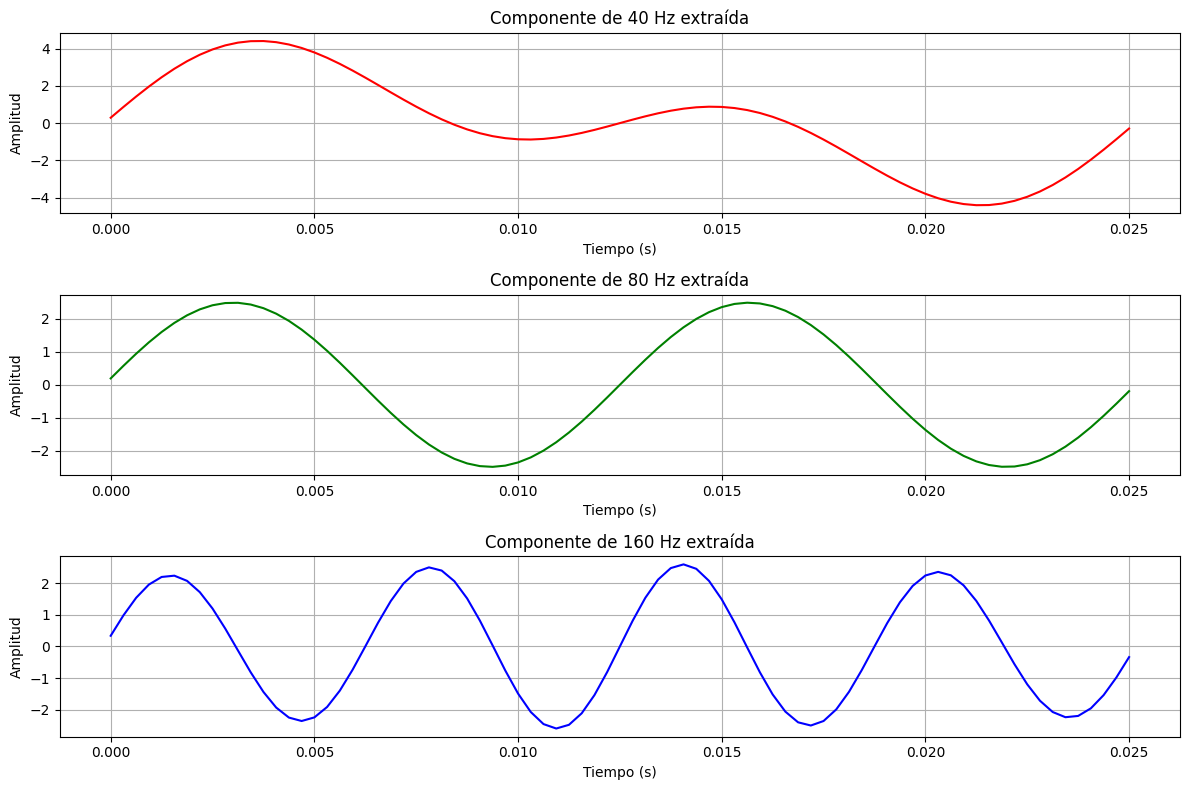

In [19]:
# Graficar componentes extraídas
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, np.real(x_40hz),'r')
plt.title('Componente de 40 Hz extraída')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, np.real(x_80hz),'g')
plt.title('Componente de 80 Hz extraída')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, np.real(x_160hz),'b')
plt.title('Componente de 160 Hz extraída')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

plt.tight_layout()
plt.show()



## 4.4 Evaluación de filtro

C:\Users\lmari\AppData\Local\Temp\ipykernel_13760\3365583332.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  F2[9:13] = F1[9:13]; #Se conservan las frecuencias entre los indices 9 y 12


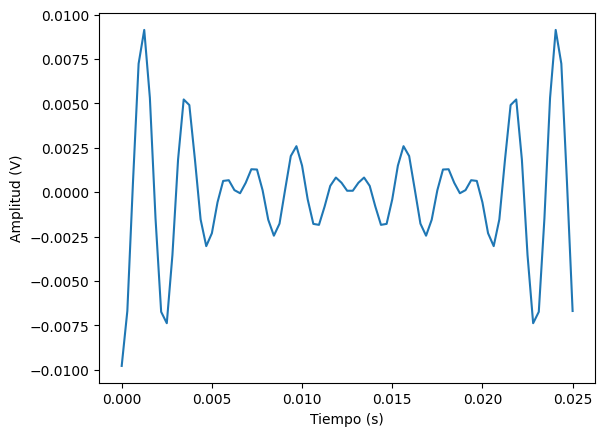

In [13]:
F1 = np.fft.fft(x);  #Aplica la fft (conviertiendo la señal en dominio de tiempo a frecuencia)
F2 = np.zeros((len(F1))); 
F2[9:13] = F1[9:13]; #Se conservan las frecuencias entre los indices 9 y 12
xr = np.fft.ifft(F2); #Recnstrucción de la señal solo con las componentes entre los indices 9 y 12.
fig = plt.figure() 
ax = fig.add_subplot(111) 
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)'); 
plt.show()

<h4>Extracción de componentes </h4>

<p>
Para extraer cada una de las componentes sinusoidales de la señal, se implementó un procedimiento basado en la Transformada Discreta de Fourier (DFT). La idea principal consiste en transformar la señal al dominio de la frecuencia mediante la FFT, conservar únicamente los bins asociados a la frecuencia de interés y posteriormente reconstruir la señal en el dominio del tiempo usando la transformada inversa (IFFT).
</p>

<p>
Inicialmente, se calcula la FFT de la señal:
</p>

$$
X[k] = \text{FFT}(x[n])
$$

<p>
Luego, se crea un vector espectral vacío con el mismo tamaño de la FFT original:
</p>

$$
X_f[k] = 0
$$

<p>
Posteriormente, se conservan únicamente los bins correspondientes a la componente deseada. Debido a que la señal original es real, la FFT presenta simetría conjugada, por lo que es necesario conservar tanto el bin positivo como su bin espejo:
</p>

$$
k_{\text{espejo}} = N-k
$$

<p>
donde:
</p>

<ul>
    <li>\(N\): número total de muestras</li>
    <li>\(k\): bin asociado a la frecuencia de interés</li>
</ul>

<p>
Una vez conservadas ambas componentes espectrales, se aplica la transformada inversa de Fourier:
</p>

$$
x_f[n] = \text{IFFT}(X_f[k])
$$

<p>
Finalmente, se toma únicamente la parte real de la señal reconstruida, ya que los pequeños componentes imaginarios generados corresponden a errores numéricos computacionales.
</p>

<p>
Este procedimiento actúa como un filtrado en frecuencia, ya que elimina todas las componentes espectrales excepto aquella que se desea reconstruir.
</p>

## 4.5 Anánalisis de señal ECG

In [20]:
# Cargar archivo .mat
data = sio.loadmat('senecg.mat')

#Transforme el vector a 1D
ecg=data['ECG'].squeeze()

fs = 250  # frecuencia de muestreo [Hz]
t = np.arange(0, 1/fs*len(ecg), 1/fs)

print(max(t))
print(len(ecg)/max(t))



4.996
250.20016012810245


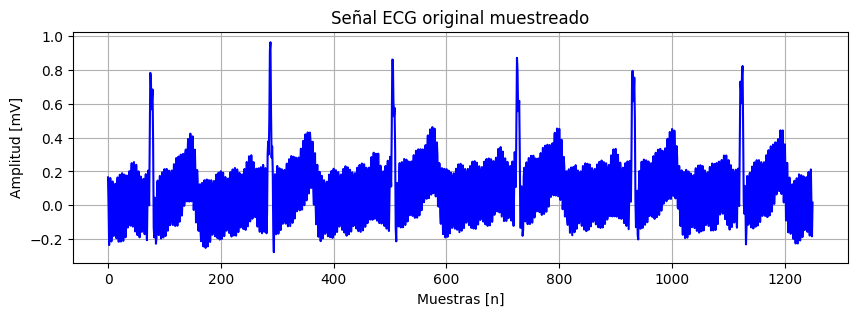

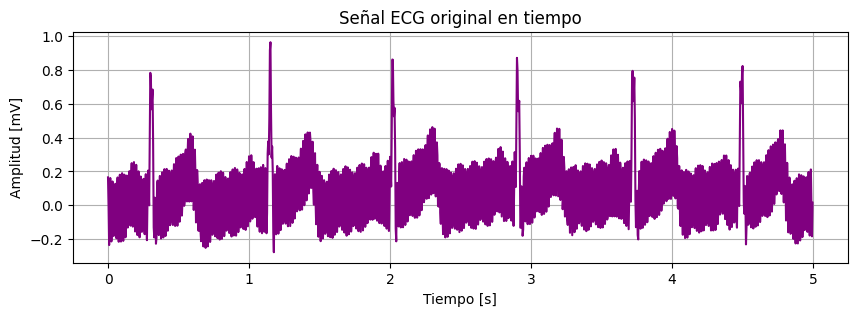

In [ ]:
#Visualizar señal original por cantidad de muestras
plt.figure(figsize=(10,3))
plt.plot(ecg, color='b')
plt.title('Señal ECG original muestreado')
plt.xlabel('Muestras [n]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

# Visualizar señal original por tiempo
plt.figure(figsize=(10,3))
plt.plot(t, ecg, color='purple')
plt.title('Señal ECG original en tiempo')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.grid(True)
plt.show()

Inicialmente, se realizó la visualización de la señal ECG tanto en función del número de muestras como en función del tiempo. Esto permitió observar el comportamiento general de la señal cardíaca y verificar la correcta adquisición de los complejos QRS, así como la periodicidad característica del ECG.
La primera gráfica representa la señal en términos de muestras discretas \(n\), mientras que la segunda gráfica muestra la misma señal respecto al tiempo utilizando el vector temporal construido a partir de la frecuencia de muestreo.

En la señal se identifica claramente la componente de interés, correspondiente al latido cardiaco, donde se observa el patrón repetitivo típico del ECG especialmente el complejo QRS con una frecuencia aproximada de seis latidos en cinco segundos, equivalente a 1.2 Hz o alrededor de 72 latidos por minuto. Estos son los componentes de baja frecuencia que deben conservarse. Sin embargo, la señal presenta un notable ruido de alta frecuencia, evidente por su apariencia densa y robusta, lo que indica una superposición importante de contenido no deseado. Este ruido tiene una amplitud considerable, variando entre –0.2 mV y 0.4 mV en las regiones planas del ECG (segmento TP), lo que dificulta la identificación precisa de las ondas P, Q, R, S y T.


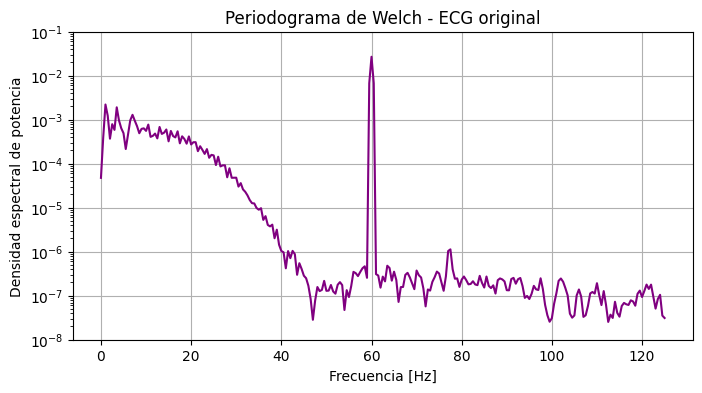

In [ ]:
# Periodograma de Welch
nperseg = 500
#Solapamiento de 50%
noverlap = int(nperseg * 0.5) 

f, Pxx = signal.welch(
    ecg, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap
    )

plt.figure(figsize=(8,4))
plt.semilogy(f, Pxx,'purple')
plt.ylim(1e-8, 1e-1)
plt.title('Periodograma de Welch - ECG original')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia')
plt.grid(True)
plt.show()

Posteriormente, se calculó el periodograma de Welch con el objetivo de estimar la densidad espectral de potencia de la señal ECG y analizar su contenido frecuencial.
El parámetro nperseg = 500 se eligió considerando la frecuencia de muestreo de 250 Hz. Este tamaño de ventana corresponde a aproximadamente dos segundos de señal, lo cual permite capturar múltiples ciclos cardiacos y lograr una estimación estable y representativa del espectro. Ventanas más pequeñas producirían una mayor variabilidad en la estimación de la densidad espectral de potencia, mientras que ventanas excesivamente grandes reducirían la capacidad de detectar cambios locales y aumentarían el costo computacional. Con 500 muestras por segmento, se obtiene un compromiso adecuado entre estabilidad espectral y resolución en frecuencia 
(Δf=nperseg/fs=0.5 Hz), lo cual es suficiente para identificar las componentes fisiológicas y las fuentes de ruido relevantes.

Para el solapamiento se empleó un solapamiento del 50%, siguiendo las recomendaciones habituales para el método de Welch. Este nivel de solapamiento mejora la consistencia entre segmentos adyacentes y reduce la varianza de la estimación espectral sin introducir redundancia excesiva. Un solapamiento menor aumentaría la variabilidad del periodograma, mientras que un solapamiento excesivo incrementaría el costo computacional sin mejoras proporcionales en la calidad de la estimación. El uso conjunto de ventana Hanning, un tamaño de segmento de 500 muestras y un solapamiento del 50% garantiza una estimación espectral confiable, estable y adecuada para identificar tanto la información biológica del ECG como las fuentes de ruido presentes en la señal.

El espectro también revela la presencia de un pico extremadamente agudo y dominante en 60 Hz, asociado al ruido de la línea eléctrica (AC). Este componente presenta la mayor densidad espectral de potencia, superando por varios órdenes de magnitud tanto a la señal biológica como al ruido de fondo. Su magnitud lo convierte en la principal fuente de interferencia y en un factor crítico para la correcta interpretación de la señal. Asimismo, se identifica un aumento del nivel de ruido en frecuencias superiores a 40 Hz, consistente con la presencia de ruido muscular (EMG) o ruido de alta frecuencia, el cual coincide con la apariencia “peluda” observada en el dominio del tiempo.

c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\lmari\miniconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


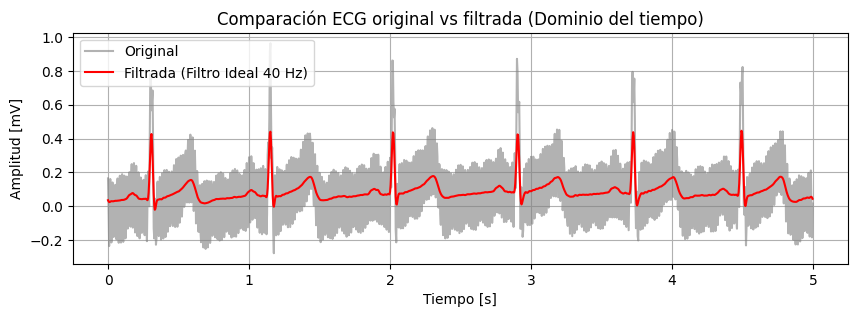

In [ ]:
f_corte = 40 # Frecuencia de corte
ind_fc = int(np.round(f_corte * len(ecg) / fs))
ind_ic = 0 # Para filtro pasa-bajas, iniciamos en 0 Hz (DC)

# Se extrae todo el contenido desde 0 Hz hasta 40 Hz.
ecg_filtrado = extraer_componente(ecg, ind_ic, ind_fc)

# Comparar señales en el Dominio del Tiempo
plt.figure(figsize=(10,3))
plt.plot(t, ecg, color='gray', label='Original', alpha=0.6)
plt.plot(t, ecg_filtrado, color='r', label='Filtrada (Filtro Ideal 40 Hz)')
plt.title('Comparación ECG original vs filtrada (Dominio del tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

Eliminación exitosa del ruido de alta frecuencia presente en la señal original. En la versión sin filtrar, representada por la curva gris, el ECG mostraba una banda gruesa y altamente contaminada, producto del ruido muscular (EMG) y, posiblemente, de armónicos asociados al ruido de línea. Este ruido hacía que la señal fuera difícil de interpretar y en algunos segmentos prácticamente ilegible. En contraste, la señal filtrada (curva roja) exhibe un trazo limpio, suave y bien definido. El filtro aplicado logró suprimir de manera efectiva todo el contenido de alta frecuencia por encima de 40 Hz, lo que confirma que la información biológica esencial del ECG se encuentra por debajo de ese umbral.

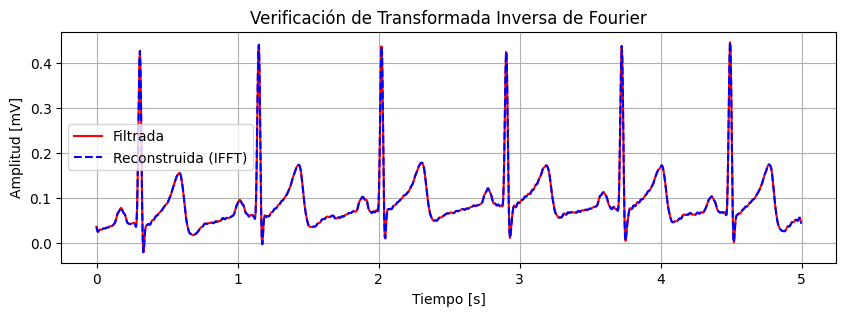

In [ ]:
# Transformada inversa de Fourier 
ECG_FFT = fft.fft(ecg_filtrado)
ecg_reconstruida = np.real(fft.ifft(ECG_FFT))

plt.figure(figsize=(10,3))
plt.plot(t, ecg_filtrado, label='Filtrada', color='r')
plt.plot(t, ecg_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

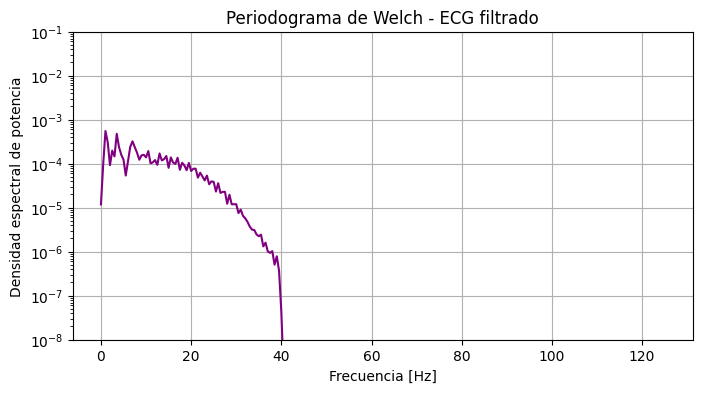

In [ ]:
# Periodograma de Welch
nperseg = 500
# Solapamiento de 50%
noverlap = int(nperseg * 0.5) 

f, Pxx = signal.welch(
    ecg_reconstruida, 
    fs=fs, 
    window='hann', 
    nperseg=nperseg, 
    noverlap=noverlap
    )

plt.figure(figsize=(8,4))
plt.semilogy(f, Pxx,'purple')
plt.ylim(1e-8, 1e-1)
plt.title('Periodograma de Welch - ECG filtrado')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad espectral de potencia')
plt.grid(True)
plt.show()

El análisis del periodograma de Welch del ECG filtrado confirma de manera cuantitativa la efectividad del proceso de filtrado aplicado. En primer lugar, se observa una eliminación completa del ruido de alta frecuencia, ya que la potencia espectral cae abruptamente a partir de los 40 Hz. Este comportamiento demuestra que el filtro pasa-bajas ideal implementado mediante la función  suprimió con éxito todo el contenido frecuencial no deseado por encima de la frecuencia de corte, incluyendo el pico de 60 Hz correspondiente al ruido de línea eléctrica que dominaba el espectro original. Al mismo tiempo, la energía de la señal se conserva plenamente dentro del intervalo clínicamente relevante, entre 0.5 Hz y 40 Hz, lo cual evidencia que el filtrado no afectó la información esencial del latido cardiaco.

La validación en el dominio del tiempo, mediante la reconstrucción utilizando la Transformada Inversa de Fourier (IFFT), demuestra la precisión matemática del proceso. En el gráfico se observa que la señal filtrada en el dominio del tiempo y su versión reconstruida mediante IFFT se superponen casi perfectamente. 

En conjunto, los resultados obtenidos permiten concluir que el proceso completo desde el análisis espectral, pasando por el diseño e implementación del filtro ideal, hasta la reconstrucción mediante IFFT fue exitoso. Se logró identificar el ruido dominante en la señal (especialmente el componente a 60 Hz), determinar el límite superior del contenido biológico del ECG (40 Hz), y aplicar un filtrado ideal capaz de eliminar de manera drástica el ruido de alta y media frecuencia sin comprometer las características fisiológicas de la señal. Como consecuencia, se obtuvo una señal limpia, estable y completamente apta para análisis clínico posterior.

## 4.6 Análisis de ECG Parkinson-control

In [ ]:

# INSPECCIÓN DEL PACIENTE CONTROL
data_control = sio.loadmat("control/C012_EP_reposo.mat")
control_crudo = data_control['data']

print("       ESTRUCTURA DEL PACIENTE CONTROL            ")
print(f"Tipo de objeto en Python: {type(control_crudo)}")
print(f"Dimensiones de la matriz original (Shape): {control_crudo.shape}")
print(f"Número de dimensiones: {control_crudo.ndim}")

# INSPECCIÓN DEL PACIENTE PARKINSON
data_parkinson = sio.loadmat("parkinson/P012_EP_reposo.mat")
parkinson_crudo = data_parkinson['data']

print("\n")
print("      ESTRUCTURA DEL PACIENTE PARKINSON           ")
print(f"Tipo de objeto en Python: {type(parkinson_crudo)}")
print(f"Dimensiones de la matriz original (Shape): {parkinson_crudo.shape}")
print(f"Número de dimensiones: {parkinson_crudo.ndim}")


       ESTRUCTURA DEL PACIENTE CONTROL            
Tipo de objeto en Python: <class 'numpy.ndarray'>
Dimensiones de la matriz original (Shape): (8, 2000, 172)
Número de dimensiones: 3


      ESTRUCTURA DEL PACIENTE PARKINSON           
Tipo de objeto en Python: <class 'numpy.ndarray'>
Dimensiones de la matriz original (Shape): (8, 2000, 140)
Número de dimensiones: 3


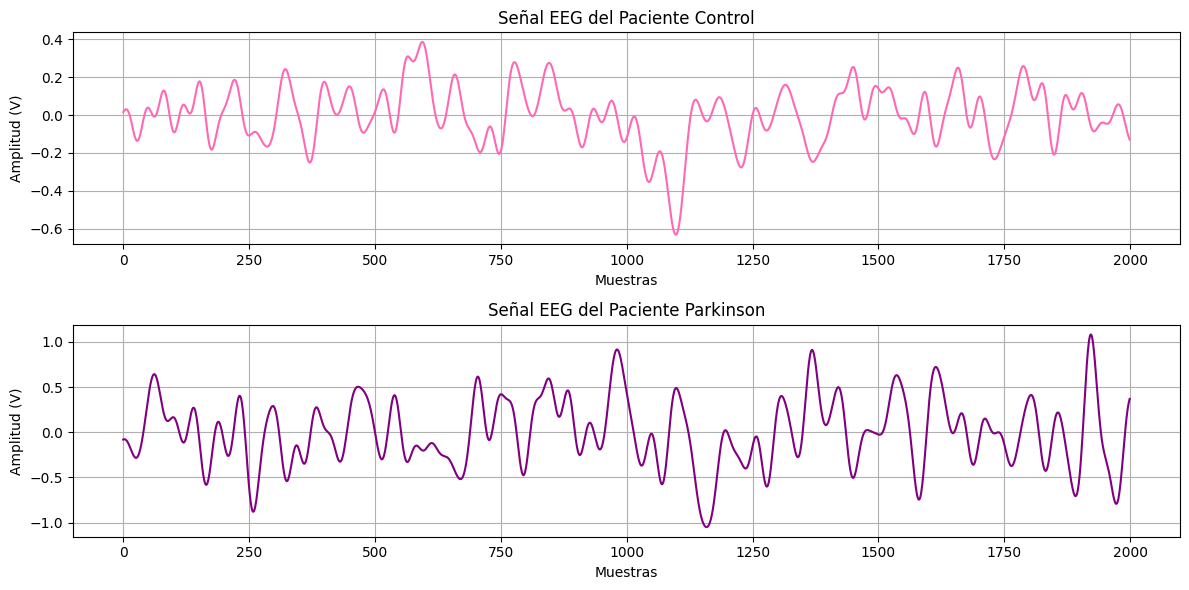

In [ ]:
#CONTROL
matriz_control = sio.loadmat("control/C012_EP_reposo.mat")['data']
# Selección el Canal 0 (que corresponde al electrodo C3)
control_epocas = matriz_control[0, :, :]
control = control_epocas.mean(axis=1)


#PARKINSON 
# Cargamos el archivo .mat y extraemos la matriz de datos
matriz_parkinson = sio.loadmat("parkinson/P012_EP_reposo.mat")['data']
parkinson_epocas = matriz_parkinson[0, :, :]
parkinson = parkinson_epocas.mean(axis=1)

# Gráfica de la señal EEG de cada Paciente.
plt.figure(figsize=(12,6))

# Paciente Control.
plt.subplot(2,1,1)
plt.plot(control,'hotpink')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.title('Señal EEG del Paciente Control')
plt.grid(True)

# Paciente Parkinson.
plt.subplot(2,1,2)
plt.plot(parkinson,'purple')
plt.xlabel('Muestras')
plt.ylabel('Amplitud (V)')
plt.title('Señal EEG del Paciente Parkinson')

plt.tight_layout()
plt.grid(True)
plt.show()

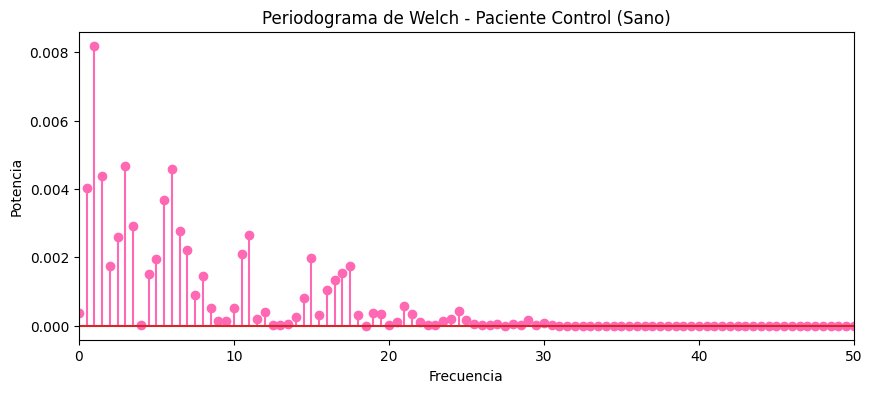

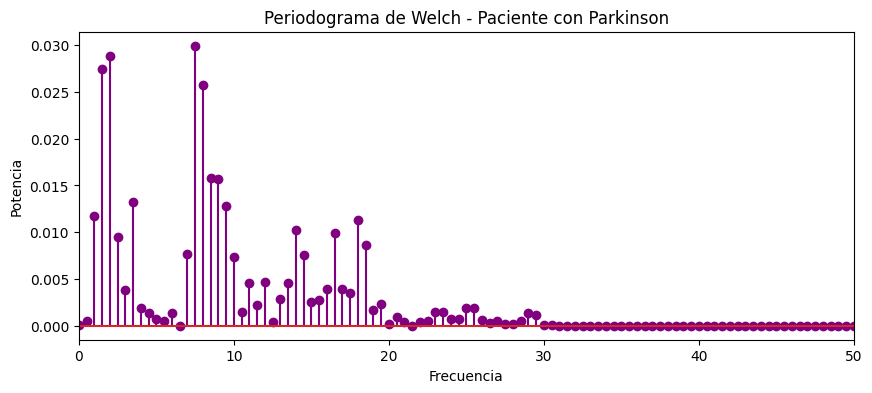

In [ ]:

fs = 1000
nperseg = 2000  # Ventana del tamaño total de la señal
f_control, Pxx_control = pwelch(control, fs=fs, window='hann', nperseg=nperseg, noverlap=0)
f_parkinson, Pxx_parkinson = pwelch(parkinson, fs=fs, window='hann', nperseg=nperseg, noverlap=0)


# Gráfica para el Paciente Control 
plt.figure(figsize=(10, 4))
plt.stem(f_control, Pxx_control,'hotpink')
plt.title('Periodograma de Welch - Paciente Control (Sano)')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.xlim([0, 50])  
plt.show()

# Gráfica para el Paciente con Parkinson
plt.figure(figsize=(10, 4))
plt.stem(f_parkinson, Pxx_parkinson,'purple')
plt.title('Periodograma de Welch - Paciente con Parkinson')
plt.xlabel('Frecuencia')
plt.ylabel('Potencia')
plt.xlim([0, 50])  
plt.show()

Al evaluar los periodogramas de Welch obtenidos para ambos pacientes en el rango de 0 a 50 Hz, se observan diferencias claras en la distribución de la potencia espectral que permiten establecer hipótesis directas sobre la actividad cerebral.

A partir de los gráficos, el análisis se centra en los siguientes puntos:

1. Alteración e Incremento de Potencia en la Banda Theta (4 a 8 Hz)
En el paciente control (sano), las frecuencias por debajo de los 10 Hz muestran amplitudes bajas y una distribución homogénea sin picos dominantes marcados. En contraste, el espectro del paciente con Parkinson exhibe sus picos de potencia más altos e intensos precisamente en el rango de los 4 a 8 Hz, alcanzando un valor cercano a 0.030 (casi cuatro veces más que el máximo del paciente sano).Técnicamente, esta concentración anormal de energía en la banda theta se asocia de forma directa con los ritmos del temblor parkinsoniano. Fisiológicamente, permite suponer la existencia de una sincronización patológica en bucle entre los ganglios basales y la corteza motora primaria (registrada en este Canal 3 / C3), actuando como un reflejo eléctrico del temblor en reposo y los movimientos involuntarios característicos de la patología.

2. Comportamiento en la Banda Beta (13 a 30 Hz)
En la gráfica del paciente control, la energía en la banda beta decrece de forma paulatina y uniforme a medida que aumenta la frecuencia, tendiendo a estabilizarse cerca de cero después de los 20 Hz. Por el contrario, el paciente con Parkinson presenta múltiples picos secundarios de potencia activos y oscilantes que se extienden de manera sostenida a lo largo de todo el rango beta (13 a 30 Hz).La persistencia de estos picos en la banda beta sobre la corteza motora sugiere un estado de "hipersincronización". En neurofisiología, la actividad beta excesiva está firmemente ligada a la dificultad para iniciar movimientos (bradicinesia) y a la rigidez muscular. El gráfico permite suponer que el cerebro del paciente mantiene un freno oscilatorio constante que bloquea la fluidez motora normal debido a la falta de dopamina.


Ambos gráficos muestran que a partir de los 30 Hz la potencia cae a niveles mínimos y se estabiliza por completo hasta los 50 Hz. Este comportamiento descarta que las diferencias observadas en las bandas bajas (theta y beta) se deban a interferencias de la línea eléctrica (que se reflejarían a los 50 o 60 Hz) o a artefactos musculares de alta frecuencia (ruido electromiográfico por muecas o parpadeos). Esto permite asumir que las variaciones en los picos de potencia son de origen puramente cortical y representan fielmente la actividad neurofisiológica alterada del paciente con Parkinson.

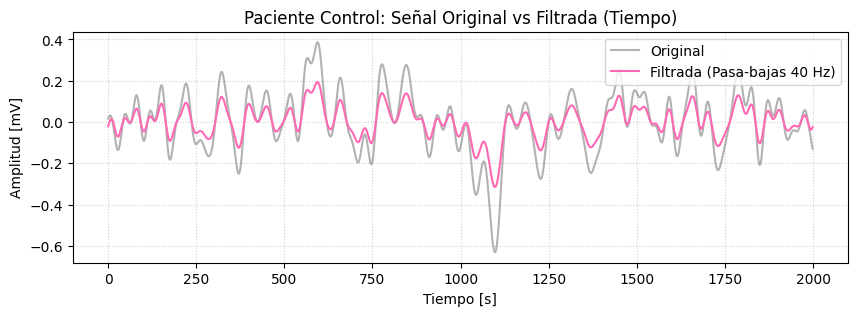

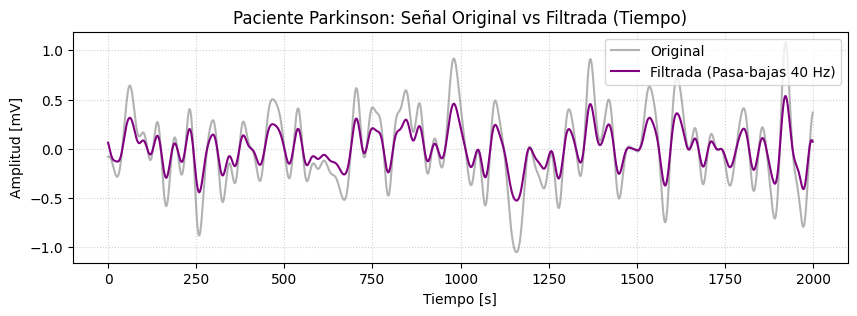

In [ ]:

# Definición de la frecuencia de corte en 40 Hz
fc = 40

# Calculo de los índices de inicio y fin para el filtro ideal
ind_inicio = 0
ind_fin = int(np.round(fc * len(control) / fs))

# Calculo de las señales filtradas usando la función del laboratorio
control_filtrada = extraer_componente(control, ind_inicio, ind_fin)
parkinson_filtrada = extraer_componente(parkinson, ind_inicio, ind_fin)

# Definición de la gráfica para el paciente de control
plt.figure(figsize=(10, 3))
plt.plot(control, color='gray', label='Original', alpha=0.6)
plt.plot(control_filtrada, color='hotpink', label='Filtrada (Pasa-bajas 40 Hz)')
plt.title('Paciente Control: Señal Original vs Filtrada (Tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Definición de la gráfica para el paciente con Parkinson
plt.figure(figsize=(10, 3))
plt.plot(parkinson, color='gray', label='Original', alpha=0.6)
plt.plot(parkinson_filtrada, color='purple', label='Filtrada (Pasa-bajas 40 Hz)')
plt.title('Paciente Parkinson: Señal Original vs Filtrada (Tiempo)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

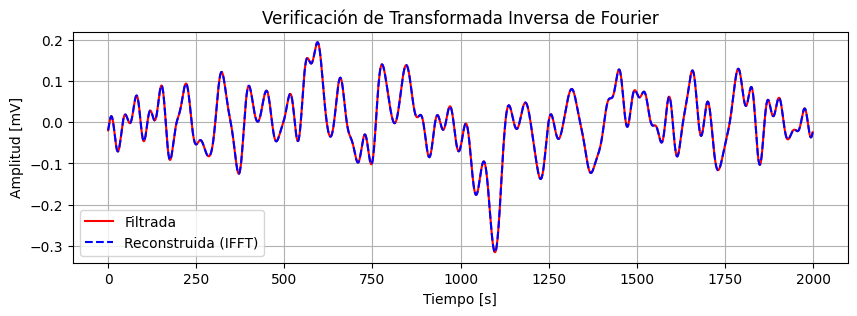

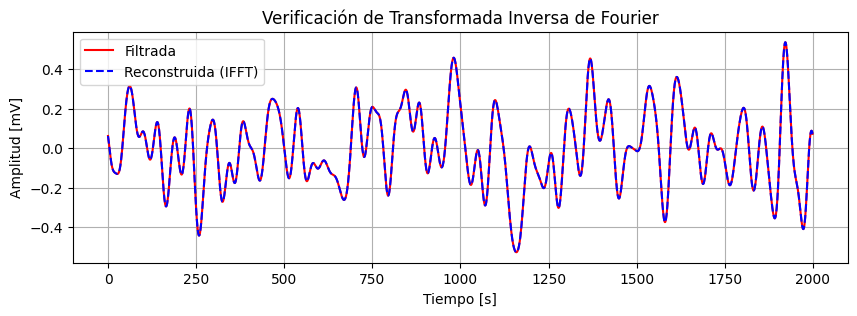

In [ ]:
# Transformada inversa de Fourier 
control_FFT = fft.fft(control_filtrada)
control_reconstruida = np.real(fft.ifft(control_FFT))

plt.figure(figsize=(10,3))
plt.plot(control_filtrada, label='Filtrada', color='r')
plt.plot(control_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()

# Transformada inversa de Fourier 
parkinson_FFT = fft.fft(parkinson_filtrada)
parkinson_reconstruida = np.real(fft.ifft(parkinson_FFT))

plt.figure(figsize=(10,3))
plt.plot(parkinson_filtrada, label='Filtrada', color='r')
plt.plot(parkinson_reconstruida, '--', color='b', label='Reconstruida (IFFT)')
plt.title('Verificación de Transformada Inversa de Fourier')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()
plt.grid(True)
plt.show()


## Conclusiones 

* Se demostró la exactitud del procesamiento digital al establecer que un factor de sobremuestreo de 20 veces la frecuencia mayor ($F_s = 3200\text{ Hz}$) es el parámetro necesario para evitar la pérdida de los picos y valles locales de la mezcla y mantener la suavidad de las curvas en el tiempo. A partir de esta tasa, la DFT localiza con precisión los tres armónicos exactos ($40\text{ Hz}$, $80\text{ Hz}$ y $160\text{ Hz}$) sin datos redundantes al limitar el gráfico a la frecuencia de Nyquist, mientras que la transformada inversa entrega una reconstrucción morfológica idéntica a la onda inicial.

* El ejercicio de filtrado en el dominio de la frecuencia evidenció que la manipulación directa de los coeficientes de la FFT permite implementar filtros ideales capaces de aislar con precisión rangos específicos y eliminar el resto del contenido. Esta técnica se confirmó nuevamente en el análisis del ECG, donde el periodograma de Welch reveló la presencia de ruido de línea eléctrica y ruido muscular. La aplicación de un filtro pasa-bajas ideal de 40 Hz permitió obtener una señal más limpia, con una morfología clara y clínicamente interpretable.



* Se estableció cuantitativamente que la patología de Parkinson altera la firma electroencefalográfica en el Canal 3 (C3) de la corteza motora primaria, registrando un incremento masivo de la potencia en la banda baja theta (4-8 Hz) que multiplica casi por cuatro los niveles del control sano, junto con picos de energía inestables y sostenidos a lo largo de toda la banda beta (13-30 Hz).

## Referencias Bibliográficas


[1] Proakis, J. G., & Manolakis, D. G. (2007). Digital Signal Processing: Principles, Algorithms, and Applications (4th ed.). Pearson Prentice Hall.

[2] Oppenheim, A. V., & Schafer, R. W. (2010). Discrete-Time Signal Processing (3rd ed.). Prentice Hall.

[3] Lathi, B. P., & Green, R. A. (2014). Linear Systems and Signals (3rd ed.). Oxford University Press.

[4] Lyons, R. G. (2010). Understanding Digital Signal Processing (3rd ed.). Prentice Hall.

[5] International 10–20 EEG Electrode Placement System. Journal of Clinical Neurophysiology, standard guidelines.

[6] Central and Central-Parietal EEG Signatures of Parkinson's Disease. (2025). arXiv preprint arXiv:2503.12392.

[7] Neurosity & PMC Neurology Research. (2025). EEG and Parkinson's: Biomarkers, Cortical Motor Activity, and Tremor Detection.